In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import json
from pathlib import Path

# Load the model and tokenizer
model_path = Path.cwd()
print(f"Loading model from: {model_path}")

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

# Load label mapping
with open(model_path / "label_mapping.json", "r") as f:
    label_mapping = json.load(f)

id2label = {int(k): v for k, v in label_mapping["id2label"].items()}
print(f"\nLabel Mapping: {id2label}")
print(f"Model loaded successfully!")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

c:\Users\SAGAR\.pyenv\pyenv-win\versions\3.8.10\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading model from: c:\Users\SAGAR\Downloads\cognitive_shift_model

Label Mapping: {0: 'affective', 1: 'cognitive', 2: 'agency'}
Model loaded successfully!
Device: cpu

Label Mapping: {0: 'affective', 1: 'cognitive', 2: 'agency'}
Model loaded successfully!
Device: cpu


In [2]:
# Define test sentences
test_sentences = [
    # Affective (emotional, feeling-based)
    "I feel so happy and excited about this opportunity",
    "This makes me very sad and disappointed",
    "I love spending time with my family",
    "I'm afraid of making mistakes",
    "This is absolutely beautiful and wonderful",
    
    # Cognitive (thinking, reasoning, knowledge)
    "I understand the concept of quantum mechanics",
    "The theory suggests that innovation drives economic growth",
    "Let me analyze this data carefully",
    "I believe the hypothesis needs further testing",
    "This problem requires logical reasoning and analysis",
    
    # Agency (control, action, motivation)
    "I will complete this project by next week",
    "I can make a difference in this community",
    "Let's take action and solve this problem together",
    "I have the power to change my circumstances",
    "We should implement these strategies immediately",
]

print("Test Sentences:")
print("=" * 60)
for i, sent in enumerate(test_sentences, 1):
    print(f"{i}. {sent}")

Test Sentences:
1. I feel so happy and excited about this opportunity
2. This makes me very sad and disappointed
3. I love spending time with my family
4. I'm afraid of making mistakes
5. This is absolutely beautiful and wonderful
6. I understand the concept of quantum mechanics
7. The theory suggests that innovation drives economic growth
8. Let me analyze this data carefully
9. I believe the hypothesis needs further testing
10. This problem requires logical reasoning and analysis
11. I will complete this project by next week
12. I can make a difference in this community
13. Let's take action and solve this problem together
14. I have the power to change my circumstances
15. We should implement these strategies immediately


In [3]:
import pandas as pd

# Run predictions
results = []

model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

with torch.no_grad():
    for sentence in test_sentences:
        # Tokenize
        inputs = tokenizer(
            sentence,
            return_tensors="pt",
            truncation=True,
            max_length=512,
            padding=True
        ).to(device)
        
        # Get predictions
        outputs = model(**inputs)
        logits = outputs.logits
        
        # Get probabilities and prediction
        probs = torch.softmax(logits, dim=-1)
        pred_id = torch.argmax(probs, dim=-1).item()
        pred_label = id2label[pred_id]
        confidence = probs[0][pred_id].item()
        
        # Store all class probabilities
        all_probs = {id2label[i]: probs[0][i].item() for i in range(len(id2label))}
        
        results.append({
            'Sentence': sentence,
            'Prediction': pred_label,
            'Confidence': f"{confidence:.4f}",
            'Affective': f"{all_probs['affective']:.4f}",
            'Cognitive': f"{all_probs['cognitive']:.4f}",
            'Agency': f"{all_probs['agency']:.4f}"
        })

# Display results in a table
df_results = pd.DataFrame(results)
print("\nPrediction Results:")
print("=" * 120)
print(df_results.to_string(index=False))



Prediction Results:
                                                  Sentence Prediction Confidence Affective Cognitive Agency
        I feel so happy and excited about this opportunity  affective     0.9944    0.9944    0.0034 0.0022
                   This makes me very sad and disappointed  affective     0.9954    0.9954    0.0028 0.0018
                       I love spending time with my family  affective     0.9929    0.9929    0.0028 0.0043
                             I'm afraid of making mistakes  affective     0.9907    0.9907    0.0079 0.0015
                This is absolutely beautiful and wonderful  affective     0.9938    0.9938    0.0039 0.0024
             I understand the concept of quantum mechanics  cognitive     0.9894    0.0085    0.9894 0.0021
The theory suggests that innovation drives economic growth  cognitive     0.9723    0.0121    0.9723 0.0156
                        Let me analyze this data carefully  cognitive     0.5467    0.0137    0.5467 0.4396
       

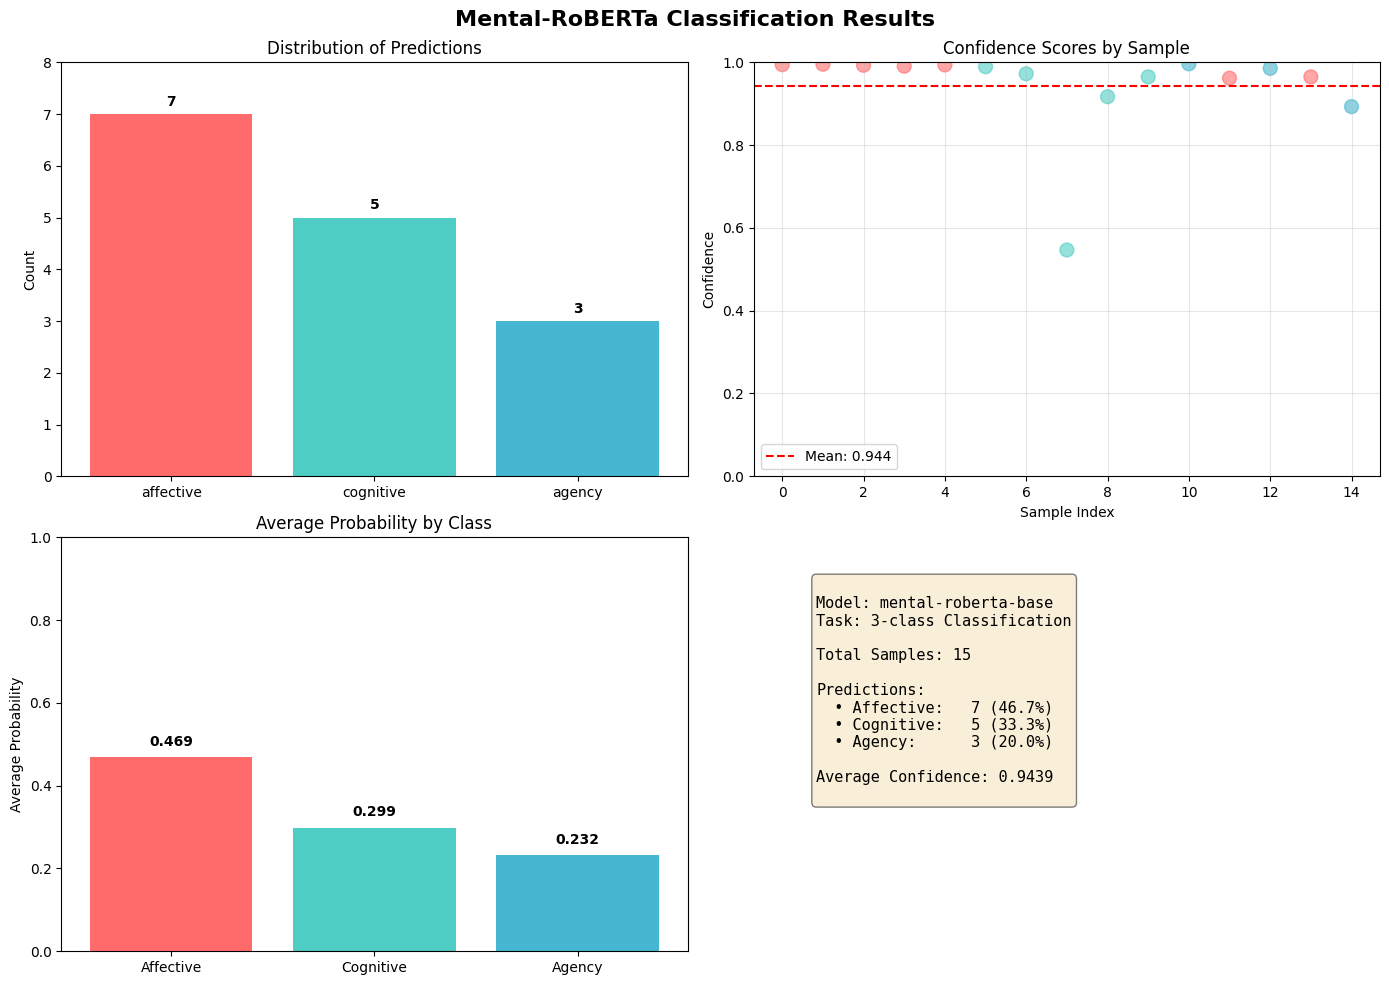


Visualization complete!


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Mental-RoBERTa Classification Results', fontsize=16, fontweight='bold')

# 1. Prediction distribution
ax = axes[0, 0]
prediction_counts = df_results['Prediction'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
ax.bar(prediction_counts.index, prediction_counts.values, color=colors)
ax.set_title('Distribution of Predictions')
ax.set_ylabel('Count')
ax.set_ylim([0, max(prediction_counts.values) + 1])
for i, v in enumerate(prediction_counts.values):
    ax.text(i, v + 0.1, str(v), ha='center', va='bottom', fontweight='bold')

# 2. Confidence scores
ax = axes[0, 1]
confidences = [float(c) for c in df_results['Confidence']]
colors_conf = ['#FF6B6B' if pred == 'affective' else '#4ECDC4' if pred == 'cognitive' else '#45B7D1' 
               for pred in df_results['Prediction']]
ax.scatter(range(len(confidences)), confidences, c=colors_conf, s=100, alpha=0.6)
ax.axhline(y=np.mean(confidences), color='r', linestyle='--', label=f'Mean: {np.mean(confidences):.3f}')
ax.set_title('Confidence Scores by Sample')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Confidence')
ax.set_ylim([0, 1])
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Average probabilities by class
ax = axes[1, 0]
avg_probs = {
    'Affective': np.mean([float(x) for x in df_results['Affective']]),
    'Cognitive': np.mean([float(x) for x in df_results['Cognitive']]),
    'Agency': np.mean([float(x) for x in df_results['Agency']])
}
bars = ax.bar(avg_probs.keys(), avg_probs.values(), color=colors)
ax.set_title('Average Probability by Class')
ax.set_ylabel('Average Probability')
ax.set_ylim([0, 1])
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

# 4. Sample statistics
ax = axes[1, 1]
ax.axis('off')
stats_text = f"""
Model: mental-roberta-base
Task: 3-class Classification

Total Samples: {len(test_sentences)}

Predictions:
  • Affective:   {prediction_counts.get('affective', 0)} ({prediction_counts.get('affective', 0)/len(test_sentences)*100:.1f}%)
  • Cognitive:   {prediction_counts.get('cognitive', 0)} ({prediction_counts.get('cognitive', 0)/len(test_sentences)*100:.1f}%)
  • Agency:      {prediction_counts.get('agency', 0)} ({prediction_counts.get('agency', 0)/len(test_sentences)*100:.1f}%)

Average Confidence: {np.mean(confidences):.4f}
"""
ax.text(0.1, 0.9, stats_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\nVisualization complete!")